In [38]:
import pandas as pd

In [39]:
fake = pd.read_csv('Datasets/Fake.csv')
true = pd.read_csv('Datasets/True.csv')

In [40]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [41]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [42]:
print('Fake Data Shape: ',fake.shape)
print('True Data Shape: ',true.shape)

Fake Data Shape:  (23481, 4)
True Data Shape:  (21417, 4)


## Lableling the fake news with 0 and true news with 1 and combining both the datasets

In [43]:
fake['authenticity'] = 0
true['authenticity'] = 1

df = pd.concat([fake,true],ignore_index=True)
df.sample(5)

,title,text,subject,date,authenticity
24469,"U.S. State Department names Russian defense, i...",WASHINGTON (Reuters) - The U.S. State Departme...,politicsNews,"October 27, 2017",1
7700,97-Year-Old Woman Dies After Being Evicted Fr...,"Marie Hatch, a 97-year-old California resident...",News,"March 4, 2016",0
34023,Cuba sending Americans to the beach during Oba...,HAVANA (Reuters) - Americans traveling to Cuba...,politicsNews,"March 3, 2016",1
4839,Trumpkins Seriously Think Their Hero Will Ret...,This is so horribly amazing that it defies des...,News,"August 31, 2016",0
21,KY GOP State Rep. Commits Suicide Over Allega...,"In this #METOO moment, many powerful men are b...",News,"December 13, 2017",0


In [44]:
df['authenticity'].value_counts()

authenticity
0    23481
1    21417
Name: count, dtype: int64

## Showing the proportions of fake and real news

In [45]:
df['authenticity'].value_counts(normalize=True)

authenticity
0    0.522985
1    0.477015
Name: proportion, dtype: float64

## Checking for null values (Here Data is absolutly clean) 

In [46]:
df.isna().mean()

title           0.0
text            0.0
subject         0.0
date            0.0
authenticity    0.0
dtype: float64

## Checking for Duplicate Data

In [47]:
df.duplicated().mean()

0.0046549957681856656

In [48]:
df.duplicated().sum()

209

In [49]:
# Dropping the duplicate values
df = df.drop_duplicates()

## Checking the Distribution of Text Length

In [50]:
df['text_len'] = df['text'].apply(lambda x : len(str(x).split()))
df['text_len'].describe()

count    44689.000000
mean       404.966502
std        351.573770
min          0.000000
25%        203.000000
50%        362.000000
75%        512.000000
max       8135.000000
Name: text_len, dtype: float64

## Visualization of News Article Word Count

In [51]:
import matplotlib.pyplot as plt

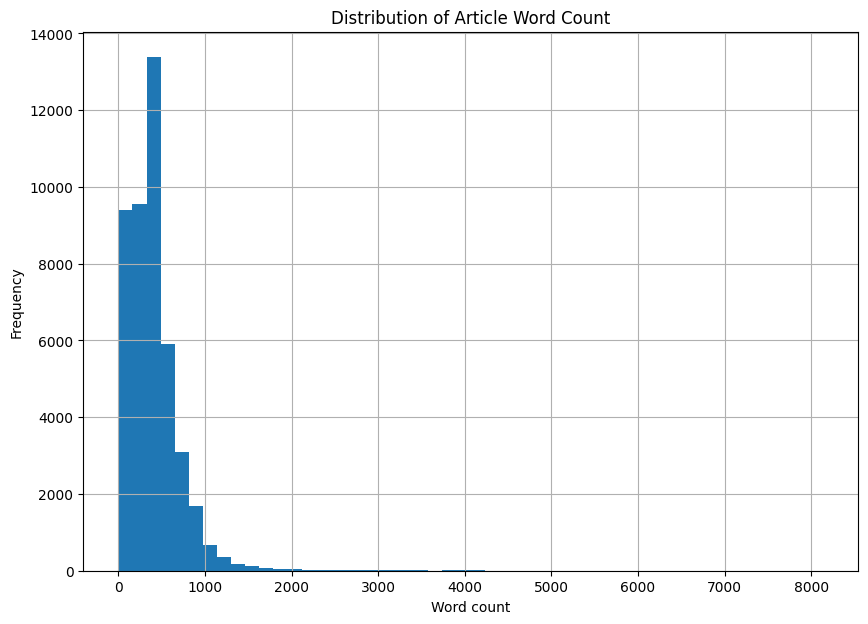

In [52]:
plt.figure(figsize=(10,7))
df['text_len'].hist(bins=50)
plt.title("Distribution of Article Word Count")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.show()

## Comparing Real vs Fake News Article Length

In [53]:
df.groupby('authenticity')['text_len'].mean()

authenticity
0    423.224167
1    384.757484
Name: text_len, dtype: float64

In [54]:
df.groupby('authenticity')['text_len'].median()

authenticity
0    363.0
1    359.0
Name: text_len, dtype: float64

## Analyzing Subjects/News Topics

In [55]:
df["subject"].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

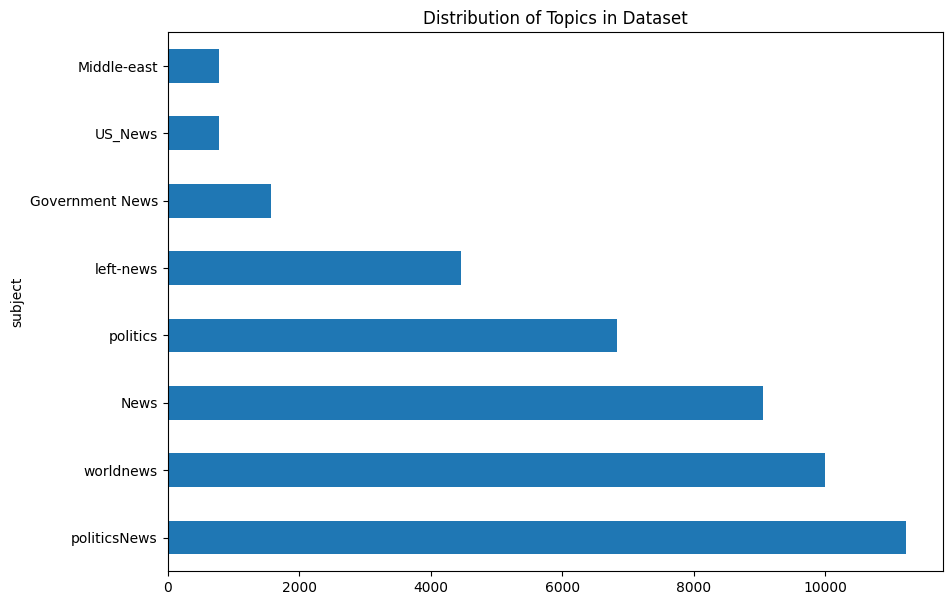

In [56]:
df["subject"].value_counts().plot(kind="barh", figsize=(10,7))
plt.title("Distribution of Topics in Dataset")
plt.show()

## WORD CLOUDS : They are a visual tool used in NLP and data analysis to show the most frequent words in a text or dataset

(-0.5, 399.5, 199.5, -0.5)

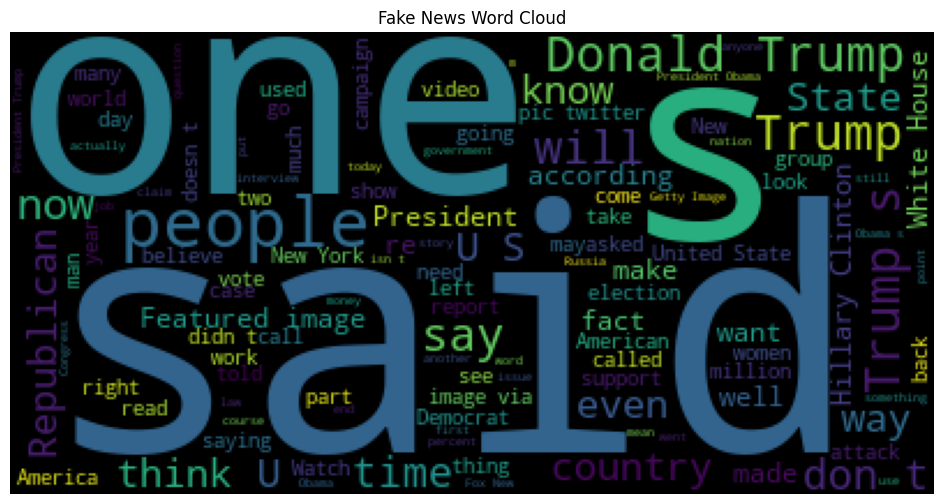

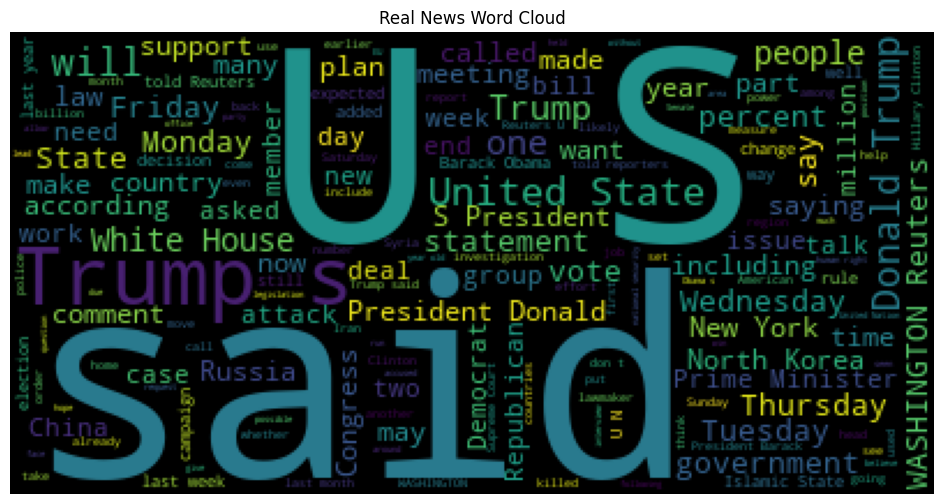

In [57]:
from wordcloud import WordCloud

fake_text = " ".join(fake["text"].astype(str))
true_text = " ".join(true["text"].astype(str))

plt.figure(figsize=(12,6))
plt.imshow(WordCloud(max_words=200).generate(fake_text))
plt.title("Fake News Word Cloud")
plt.axis("off")

plt.figure(figsize=(12,6))
plt.imshow(WordCloud(max_words=200).generate(true_text))
plt.title("Real News Word Cloud")
plt.axis("off")


## NLP Preprocessing Exploration

In [58]:
import re 
import string 
import nltk

In [59]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Muks\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [60]:
from nltk.corpus import stopwords

In [62]:
STOPWORDS = set(stopwords.words("english"))

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+"," ",text)
    text = re.sub(r"[%s]" % re.escape(string.punctuation)," ",text)
    text = re.sub(r"\s+"," ",text)
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_text)

print("Nulls in clean_text:", df["clean_text"].isna().sum())
print("Empty clean_text rows:", (df["clean_text"].str.strip() == "").sum())

df[["text", "clean_text"]].head(10)

Nulls in clean_text: 0
Empty clean_text rows: 716


,text,clean_text
0,Donald Trump just couldn t wish all Americans ...,donald trump wish americans happy new year lea...
1,House Intelligence Committee Chairman Devin Nu...,house intelligence committee chairman devin nu...
2,"On Friday, it was revealed that former Milwauk...",friday revealed former milwaukee sheriff david...
3,"On Christmas day, Donald Trump announced that ...",christmas day donald trump announced would bac...
4,Pope Francis used his annual Christmas Day mes...,pope francis used annual christmas day message...
5,The number of cases of cops brutalizing and ki...,number cases cops brutalizing killing people c...
6,Donald Trump spent a good portion of his day a...,donald trump spent good portion day golf club ...
7,In the wake of yet another court decision that...,wake yet another court decision derailed donal...
8,Many people have raised the alarm regarding th...,many people raised alarm regarding fact donald...
9,Just when you might have thought we d get a br...,might thought get break watching people kiss d...


In [63]:
df['clean_text'] = df['clean_text'].fillna('').astype(str)

## N-Gram Analysis 

In [64]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2),stop_words='english',max_features=20)
X = vectorizer.fit_transform(df[df.authenticity==0]['clean_text'])
vectorizer.get_feature_names_out()

array(['21st century', 'barack obama', 'century wire', 'donald trump',
       'fake news', 'featured image', 'fox news', 'getty images',
       'hillary clinton', 'new york', 'pic twitter', 'president obama',
       'president trump', 'social media', 'supreme court',
       'trump campaign', 'twitter com', 'united states', 'white house',
       'year old'], dtype=object)

In [65]:
df.to_csv('Datasets\cleaned_data.csv',index=False)